# 07 PyTorch Experiment Tracking

Machine learning is very experimental.

In order to figure out which experiments are worth pursuing, that's where **experiment tracking** comes in, it helps you to figure out what doesn't work so you can figure out what **does** work.

In this notebook, we're going to see an example of programmatically tracking experiments.

In [1]:
import torch
import torchvision
torch.__version__, torchvision.__version__

('2.6.0', '0.21.0')

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
device

'mps'

In [3]:
# set seeds
def set_seeds(seed: int = 42):
    """Sets random sets for torch operations.
    
    Args:
        seed (int): The seed to set for random number generation. Defaults to 42.
    """
    torch.manual_seed(seed)
    if device == "cuda":
        torch.cuda.manual_seed_all(seed)

In [4]:
set_seeds()

## 1. Get data

Want to get pizza, steak, sushi, images.

So we can run experiments building FoodVision Mini and see which model performs best.

In [5]:
import os
import zipfile

from pathlib import Path

import requests

def download_data(url: str, destination: str, remove_source: bool = True) -> Path:
    """Downloads a file from a URL and saves it to a destination.
    
    Args:
        url (str): The URL to download the file from.
        destination (str): The path to save the downloaded file.
        remove_source (bool): Whether to remove the source file after extraction. Defaults to True.
    """
    # Setup path to data folder
    data_path = Path(destination)
    image_path = data_path / destination
    
    # If the image folder already exists, doesn't exist, create it
    if image_path.is_dir():
        print(f"[INFO] {image_path} already exists, skipping download...")
    else:
        print(f"[INFO] Did not find {image_path}, creating it...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download the data
        print(f"[INFO] Downloading data from {url} to {image_path}...")
        target_file = Path(url).name
        with open(data_path / target_file, "wb") as f:
            response = requests.get(url)
            print(f"[INFO] Downloading {target_file}... from {url}")
            f.write(response.content)
            
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...")
            zip_ref.extractall(image_path)
            
        # Remove .zip file if needed
        if remove_source:
            print(f"[INFO] Removing {target_file}...")
            os.remove(data_path / target_file)
            
    return image_path

In [6]:
image_path = download_data(url="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip", destination="data")

[INFO] data/data already exists, skipping download...


## 2. Create Datasets adn DataLoaders

### 2.1 Create DataLoaders with manual transforms

The goal with transforms is to ensure your custom data is formatted in a reproducible way as well as a way that will suit pretrained models.

In [7]:
# SEtup directories
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/data/train'), PosixPath('data/data/test'))

In [8]:
# Setup ImageNet normilization levels
# See here: https://pytorch.org/vision/stable/models.html#torchvision.models.resnet50
normalize = torchvision.transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# Create transform pipeline manually
from torchvision import transforms
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

print(f"Manually created transforms: {manual_transforms}")

# Create DataLoaders
from going_modular.going_modular import data_setup
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=32
)
train_dataloader, test_dataloader, class_names

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


(<torch.utils.data.dataloader.DataLoader at 0x105fda870>,
 ['pizza', 'steak', 'sushi'])

### 2.2 Create DataLoaders using automatically created transforms

The same principle applies for automatic transforms: we want our custom data in the same format as a pretrained model was trained on.

In [9]:
# Setup dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

# Setup pretrained weights (plenty of these weights available in torchvision.models v0.13+)
import torchvision
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT    # "DEFAULT" = best available

# Get transforms from weights (these are the transforms used to train a particular model or obtain a particular set of weights)
automatic_transforms = weights.transforms()
print(f"Automatically created transforms: {automatic_transforms}")

# Create DataLoaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=automatic_transforms,
    batch_size=32
)

Automatically created transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


## 3. Getting a pretrained model, freeze the base layers and change the classifier head

In [10]:
# Note: This is how a pretrained model would be created prior to torchvision v0.13
# model = torchvision.models.efficientnet_b0(pretrained=True).to(device)
model = torchvision.models.efficientnet_b0(weights=weights).to(device)  # torchvision v0.13+ uses weights instead of pretrained

# Setup the model with the pretrained weights and send it to the target device
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [11]:
# Freeze all base layers by setting requires_grad to False
for param in model.parameters():
    # print(param)
    param.requires_grad = False

In [12]:
# Adjust the classifier head
import torch.nn as nn
from torchinfo import summary

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
).to(device)

# Check the model summary
from torchinfo import summary
summary(model, 
        input_size=(32, 3, 224, 224), 
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"],
        device=device)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

## 4. Train a single model and track results

In [13]:
# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

To track experiments, we're going to TensorBoard: https://www.tensorflow.org/tensorboard/

And to interact with TensorBoard, we can use PyTorch's SummaryWriter - https://pytorch.org/docs/stable/tensorboard.html

* Also see here: https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter

In [14]:
# Setup a SummaryWriter
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()
writer

In [15]:
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
def train_step(model: torch.nn.Module, 
                dataloader: torch.utils.data.DataLoader, 
                loss_fn: torch.nn.Module, 
                optimizer: torch.optim.Optimizer,
                device: torch.device) -> Tuple[float, float]:
    """Trains a PyTorch model for a single epoch.

    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).

    Args:
        model: A PyTorch model to be trained.
        dataloader: A DataLoader instance for the model to be trained on.
        loss_fn: A PyTorch loss function to minimize.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A tuple of training loss and training accuracy metrics.
        In the form (train_loss, train_accuracy). For example:
        
        (0.1112, 0.8743)
    """
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module, 
                dataloader: torch.utils.data.DataLoader, 
                loss_fn: torch.nn.Module,
                device: torch.device) -> Tuple[float, float]:
    """Tests a PyTorch model for a single epoch.

    Turns a target PyTorch model to "eval" mode and then performs
    a forward pass on a testing dataset.

    Args:
        model: A PyTorch model to be tested.
        dataloader: A DataLoader instance for the model to be tested on.
        loss_fn: A PyTorch loss function to calculate loss on the test data.
        device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A tuple of testing loss and testing accuracy metrics.
        In the form (test_loss, test_accuracy). For example:
        
        (0.0223, 0.8985)
    """
    # Put model in eval mode
    model.eval() 

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc
### New: Experiment tracking with TensorBoard
# See SummaryWriter documentation for more details: https://pytorch.org/docs/stable/tensorboard.html
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
                    train_acc: [...],
                    test_loss: [...],
                    test_acc: [...]} 
    For example if training for epochs=2: 
                    {train_loss: [2.0616, 1.0537],
                    train_acc: [0.3945, 0.3945],
                    test_loss: [1.2641, 1.5706],
                    test_acc: [0.3400, 0.2973]} 
    """
    # Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
  
    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device)
      
        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        writer.add_scalars(
            main_tag="Loss",
            tag_scalar_dict={
                "Train Loss": 0.5,
                "Test Loss": 0.4
                },
                global_step=0
            )
        writer.add_scalars(
            main_tag="Accuracy",
            tag_scalar_dict={
                "Train Accuracy": 0.8,
                "Test Accuracy": 0.7
            },
            global_step=0
        )
        writer.add_graph(model, input_to_model=torch.randn(32, 3, 224, 224).to(device))

        # Close the writer
    writer.close()

    # Return the filled results at the end of the epochs
    return results

In [16]:
# Train model
# Note: not using engine.train(), since we updated the train() function above
set_seeds()
results = train(model = model,
                train_dataloader = train_dataloader,
                test_dataloader = test_dataloader,
                optimizer = optimizer,
                loss_fn = loss_fn,
                epochs = 5,
                device = device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0777 | train_acc: 0.4375 | test_loss: 0.8684 | test_acc: 0.7330
Epoch: 2 | train_loss: 0.9106 | train_acc: 0.6445 | test_loss: 0.7958 | test_acc: 0.7538
Epoch: 3 | train_loss: 0.7744 | train_acc: 0.7422 | test_loss: 0.6796 | test_acc: 0.8655
Epoch: 4 | train_loss: 0.6667 | train_acc: 0.8789 | test_loss: 0.6638 | test_acc: 0.8665
Epoch: 5 | train_loss: 0.7081 | train_acc: 0.6914 | test_loss: 0.6751 | test_acc: 0.7746


## 5. View our model's results with TensorBoard

There are a few ways to view TensorBoard results, see them here:

In [17]:
# Let's view our experiments from within the notebook
%load_ext tensorboard
%tensorboard --logdir runs

## 6. Create a function to prepare a `SummaryWriter` instance

By default our `SummaryWriter()` class saves to `log_dir`.

How about if we wanted to save different experiments to different folders?

In essenc, one experiment = one folder.
* Experiment data/timestamp
* Experiment name
* Model name
* Extra - is there anything else that should be tracked?

Let's create a function to create a `SummaryWriter()` instance to take all of these things into account.

So ideally we end up tracking experiments to a directory:

`runs/YYYY-MM-DD/experiment_name/model_name/extra`

In [18]:
from torch.utils.tensorboard import SummaryWriter

def create_writer(experiment_name: str,
                  model_name: str,
                  extra: str=None):
    """Creates a torch.utils.tensorboard.writer.SummaryWriter() instance tracking to a specific directory.
    Args:
        experiment_name (str): The name of the experiment.
        model_name (str): The name of the model.
        extra (str, optional): Any extra information to add to the directory. Defaults to None.
    """
    from datetime import datetime
    import os
    
    # Get timestamp of current date in reverse order
    timestamp = datetime.now().strftime("%Y%m%d")

    if extra:
        # Create log directory path
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name, extra)
    else:
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name)
    print(f"[INFO] Creating log directory at: {log_dir}")
    return SummaryWriter(log_dir=log_dir)

In [19]:
example_writer = create_writer(
    experiment_name="data_10_percent",
    model_name="effnet_b0",
    extra="5_epochs"
)

example_writer

[INFO] Creating log directory at: runs/20250331/data_10_percent/effnet_b0/5_epochs


### 6.1 Update the `train()` function to include a `writer` parameter

In [20]:
# Update train() to use create_writer()...
import torch.utils.tensorboard
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
def train_step(model: torch.nn.Module, 
                dataloader: torch.utils.data.DataLoader, 
                loss_fn: torch.nn.Module, 
                optimizer: torch.optim.Optimizer,
                device: torch.device) -> Tuple[float, float]:
    """Trains a PyTorch model for a single epoch.

    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).

    Args:
        model: A PyTorch model to be trained.
        dataloader: A DataLoader instance for the model to be trained on.
        loss_fn: A PyTorch loss function to minimize.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A tuple of training loss and training accuracy metrics.
        In the form (train_loss, train_accuracy). For example:
        
        (0.1112, 0.8743)
    """
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module, 
                dataloader: torch.utils.data.DataLoader, 
                loss_fn: torch.nn.Module,
                device: torch.device) -> Tuple[float, float]:
    """Tests a PyTorch model for a single epoch.

    Turns a target PyTorch model to "eval" mode and then performs
    a forward pass on a testing dataset.

    Args:
        model: A PyTorch model to be tested.
        dataloader: A DataLoader instance for the model to be tested on.
        loss_fn: A PyTorch loss function to calculate loss on the test data.
        device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A tuple of testing loss and testing accuracy metrics.
        In the form (test_loss, test_accuracy). For example:
        
        (0.0223, 0.8985)
    """
    # Put model in eval mode
    model.eval() 

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc
### New: Experiment tracking with TensorBoard
# See SummaryWriter documentation for more details: https://pytorch.org/docs/stable/tensorboard.html
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          writer: torch.utils.tensorboard.writer.SummaryWriter) -> Dict[str, List]:
    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
                    train_acc: [...],
                    test_loss: [...],
                    test_acc: [...]} 
    For example if training for epochs=2: 
                    {train_loss: [2.0616, 1.0537],
                    train_acc: [0.3945, 0.3945],
                    test_loss: [1.2641, 1.5706],
                    test_acc: [0.3400, 0.2973]} 
    """
    # Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
  
    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device)
      
        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        if writer:
            writer.add_scalars(
                main_tag="Loss",
                tag_scalar_dict={
                    "Train Loss": 0.5,
                    "Test Loss": 0.4
                    },
                    global_step=0
                )
            writer.add_scalars(
                main_tag="Accuracy",
                tag_scalar_dict={
                    "Train Accuracy": 0.8,
                    "Test Accuracy": 0.7
                },
                global_step=0
            )
            writer.add_graph(model, input_to_model=torch.randn(32, 3, 224, 224).to(device))

            # Close the writer
            writer.close()
        else:
            pass
    # Return the filled results at the end of the epochs
    return results

## 7. Setting up a series of modelling experiments

* Setup 2x modelling experiments with effnetb0, pizza, steak, sushi data and train one model for 5 epochs and another model for 10 epochs.

### 7.1 What kind of experiments should you run?

The number of machine learning experiments you can run, is like the number of different models you can build... almost limitless.

However, you can't test everything...

So what should you test?
* Change the number of epochs
* Change the number of hidden layers/units
* Change the amount of data (right now we're using 10% of the Food101 dataset for pizza, steak, sushi)
* Change the learning rate
* Try different kinds of data augmentation
* Choose a different model architecture

This is why transfer learning is so powerful, because, it's a working model that you can apply to your own 

### 7.2 What experiments are we going to run?

We're going to run three dials:
1. Model size - EffnetB0 vs EffnetB2 (in terms of number of parameters)
2. Dataset size - 10% of pizza, steak, sushi images vs 20% (generally more data = better results)
3. Training time - 5 epochs vs 10 epochs (generally longer training time = better results, up to a point)

To begin, we're still keeping things relatively small so that our experiments run quickly.

Our goal: a model that is well performing but still small enough to run on a mobile device or web browser, so FoodVision Mini can come to life.

If you had infinite compute + time, you should basically always choose the biggest model and biggest dataset you can.

### 7.3 Download different dataset

We want two datasets:

1. Pizza, steak, sushi 10% - https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
2. Pizza, steak, sushi 20% - https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip 

In [21]:
# Download 10 percent and 20 percent datasets
data_10_percent_path = download_data(url="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip", destination="pizza_steak_sushi")

data_20_percent_path = download_data(url="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip", destination="pizza_steak_sushi_20_percent")

[INFO] pizza_steak_sushi/pizza_steak_sushi already exists, skipping download...
[INFO] pizza_steak_sushi_20_percent/pizza_steak_sushi_20_percent already exists, skipping download...


### 7.4 Transform Datasets and Create DataLoaders

We'll to transform our data in a few ways:

1. Resize the image to (224, 224)
2. Make sure image tensor values are between [0, 1]
3. Normalize the images so they have the same data distribution as ImageNet

In [22]:
# Setup training directory paths
train_dir_10_percent = data_10_percent_path / "train"
train_dir_20_percent = data_20_percent_path / "train"

# Setup the test directory
test_dir = data_10_percent_path / "test"

train_dir_10_percent, train_dir_20_percent, test_dir

(PosixPath('pizza_steak_sushi/pizza_steak_sushi/train'),
 PosixPath('pizza_steak_sushi_20_percent/pizza_steak_sushi_20_percent/train'),
 PosixPath('pizza_steak_sushi/pizza_steak_sushi/test'))

In [23]:
from torchvision import transforms

# Setup ImageNet normalization levels
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Compose transforms into a pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

In [24]:
BATCH_SIZE = 32

# Create 10% training and test DataLoaders
train_dataloader_10_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_10_percent,
                                                                                          test_dir=test_dir,
                                                                                          transform=simple_transform,
                                                                                          batch_size=BATCH_SIZE)

# Create 20% training and test DataLoaders
train_dataloader_20_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                          test_dir=test_dir,
                                                                                          transform=simple_transform,
                                                                                          batch_size=BATCH_SIZE)

print(f"Number of batches of size {BATCH_SIZE} in 10% train data: {len(train_dataloader_10_percent)}")
print(f"Number of batches of size {BATCH_SIZE} in 20% train data: {len(train_dataloader_20_percent)}")
print(f"Number of batches of size {BATCH_SIZE} in 10% test data: {len(test_dataloader)}")
print(f"Class names: {class_names}")

Number of batches of size 32 in 10% train data: 8
Number of batches of size 32 in 20% train data: 15
Number of batches of size 32 in 10% test data: 3
Class names: ['pizza', 'steak', 'sushi']


### 7.5 Create feature extractor models

We want two functions:
1. Creates a `torchvision.models.efficientnet_b0()` feature extractor with a frozen backbone/base layers and a custom classifier head.(EffNetB0)
2. Creates a `torchvision.models.efficientnet_b2()` feature extractor with a frozen backbone/base layers and a custom classifier head.(EffNetB2)

In [25]:
import torchvision

# Create an EffNetB2
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT   # "DEFAULT" = best available
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

effnetb2

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [26]:
import torchvision
from torch import nn

OUT_FEATURES = len(class_names)

# Create an EffNetB0 feature extractor
def create_effnetb0():
    # Get the weights and setup a model
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model = torchvision.models.efficientnet_b0(weights=weights)
    
    # Freeze the base model layers
    for param in model.features.parameters():
        param.requires_grad = False
        
    # Change the classifier head
    set_seeds()
    model.classifier = nn.Sequential(
        nn.Dropout(0.2, inplace=True),
        nn.Linear(in_features=1280, out_features=OUT_FEATURES)
    ).to(device)
    
    # Give the model a name
    model.name = "effnetb0"
    print(f"[INFO] Created new {model.name} model...")
    return model

In [27]:
created_model_test = create_effnetb0()

[INFO] Created new effnetb0 model...


In [28]:
summary(model=created_model_test,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [29]:
import torchvision
from torch import nn

OUT_FEATURES = len(class_names)

# Create an EffNetB0 feature extractor
def create_effnetb2():
    # Get the weights and setup a model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    model = torchvision.models.efficientnet_b2(weights=weights)
    
    # Freeze the base model layers
    for param in model.features.parameters():
        param.requires_grad = False
        
    # Change the classifier head
    set_seeds()
    model.classifier = nn.Sequential(
        nn.Dropout(0.2, inplace=True),
        nn.Linear(in_features=1408, out_features=OUT_FEATURES)
    ).to(device)
    
    # Give the model a name
    model.name = "effnetb2"
    print(f"[INFO] Created new {model.name} model...")
    return model

In [30]:
created_model_test_effnetb2 = create_effnetb2()

[INFO] Created new effnetb2 model...


In [31]:
summary(model=created_model_test_effnetb2,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

## 7.6 Create experiments and set up training code

In [32]:
# Create epoch list
num_epochs = [5, 10]

# Create models list (need to create a new model for each experiment)
models = ["effnetb0", "effnetb2"]

# Create a DataLoaders dictionary
train_dataloaders = {"data_10_percent": train_dataloader_10_percent,
                     "data_20_percent": train_dataloader_20_percent}

In [33]:
%%time
from going_modular.going_modular.utils import save_model

# Set seeds
set_seeds(42)

# Keep track of experiment numbers
experiment_number = 0

# Loop through each DataLoader
for dataloader_name, train_dataloader in train_dataloaders.items():
    # Loop through the epochs
    for epochs in num_epochs:
        # Loop through each name and create a new model instance
        for model_name in models:
            # Print out info
            experiment_number += 1
            print(f"[INFO] Experiment number: {experiment_number}")
            print(f"[INFO] Model: {model_name}")
            print(f"[INFO] DataLoader: {dataloader_name}")
            print(f"[INFO] Number of epochs: {epochs}")
            
            # Select and create the model
            if model_name == "effnetb0":
                model = create_effnetb0()
            else:
                model = create_effnetb2()
            
            # Create a new loss and optimizer for every model
            loss_fn = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
            
            # Train the target model with target dataloader 
            # Note: using train() rather model.engine.train() since we updated the train() function above
            train(model=model.to(device),
                  train_dataloader=train_dataloader,
                  test_dataloader=test_dataloader,
                  optimizer=optimizer,
                  loss_fn=loss_fn,
                  epochs=epochs,
                  device=device,
                  writer=create_writer(experiment_name=dataloader_name,
                                       model_name=model_name,
                                       extra=f"{epochs}_epochs"))
            
            # Save the model to file so we can import it later if need be
            save_filepath = f"07_{model_name}_{dataloader_name}_{epochs}_epochs.pth"
            save_model(model=model,
                       target_dir="models",
                       model_name=save_filepath)
            print("-"*50+"\n")
        

[INFO] Experiment number: 1
[INFO] Model: effnetb0
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 5
[INFO] Created new effnetb0 model...
[INFO] Creating log directory at: runs/20250331/data_10_percent/effnetb0/5_epochs


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0624 | train_acc: 0.4648 | test_loss: 0.9344 | test_acc: 0.4574
Epoch: 2 | train_loss: 0.9364 | train_acc: 0.5781 | test_loss: 0.8267 | test_acc: 0.6108
Epoch: 3 | train_loss: 0.8002 | train_acc: 0.6914 | test_loss: 0.7180 | test_acc: 0.8352
Epoch: 4 | train_loss: 0.7128 | train_acc: 0.7773 | test_loss: 0.6182 | test_acc: 0.8968
Epoch: 5 | train_loss: 0.6097 | train_acc: 0.8906 | test_loss: 0.5751 | test_acc: 0.8968
[INFO] Saving model to: models/07_effnetb0_data_10_percent_5_epochs.pth
--------------------------------------------------

[INFO] Experiment number: 2
[INFO] Model: effnetb2
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 5
[INFO] Created new effnetb2 model...
[INFO] Creating log directory at: runs/20250331/data_10_percent/effnetb2/5_epochs


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0851 | train_acc: 0.3672 | test_loss: 0.9368 | test_acc: 0.6913
Epoch: 2 | train_loss: 0.8785 | train_acc: 0.7656 | test_loss: 0.8830 | test_acc: 0.7121
Epoch: 3 | train_loss: 0.8650 | train_acc: 0.6758 | test_loss: 0.7946 | test_acc: 0.7746
Epoch: 4 | train_loss: 0.7069 | train_acc: 0.8594 | test_loss: 0.6779 | test_acc: 0.9072
Epoch: 5 | train_loss: 0.6941 | train_acc: 0.7578 | test_loss: 0.6259 | test_acc: 0.8968
[INFO] Saving model to: models/07_effnetb2_data_10_percent_5_epochs.pth
--------------------------------------------------

[INFO] Experiment number: 3
[INFO] Model: effnetb0
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 10
[INFO] Created new effnetb0 model...
[INFO] Creating log directory at: runs/20250331/data_10_percent/effnetb0/10_epochs


...

Epoch: 1 | train_loss: 0.9780 | train_acc: 0.5583 | test_loss: 0.7684 | test_acc: 0.8153
Epoch: 2 | train_loss: 0.7100 | train_acc: 0.7771 | test_loss: 0.6569 | test_acc: 0.8456
Epoch: 3 | train_loss: 0.5645 | train_acc: 0.8688 | test_loss: 0.5528 | test_acc: 0.9280
Epoch: 4 | train_loss: 0.5023 | train_acc: 0.8542 | test_loss: 0.5063 | test_acc: 0.9280
Epoch: 5 | train_loss: 0.4516 | train_acc: 0.8812 | test_loss: 0.4357 | test_acc: 0.9489
[INFO] Saving model to: models/07_effnetb2_data_20_percent_5_epochs.pth
--------------------------------------------------

[INFO] Experiment number: 7
[INFO] Model: effnetb0
[INFO] DataLoader: data_20_percent
[INFO] Number of epochs: 10
[INFO] Created new effnetb0 model...
[INFO] Creating log directory at: runs/20250331/data_20_percent/effnetb0/10_epochs


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9505 | train_acc: 0.6167 | test_loss: 0.6602 | test_acc: 0.8655
Epoch: 2 | train_loss: 0.6958 | train_acc: 0.8021 | test_loss: 0.5821 | test_acc: 0.9176
Epoch: 3 | train_loss: 0.5850 | train_acc: 0.8458 | test_loss: 0.5025 | test_acc: 0.8977
Epoch: 4 | train_loss: 0.4662 | train_acc: 0.8729 | test_loss: 0.4115 | test_acc: 0.9280
Epoch: 5 | train_loss: 0.4542 | train_acc: 0.8542 | test_loss: 0.3878 | test_acc: 0.9280
Epoch: 6 | train_loss: 0.4245 | train_acc: 0.8521 | test_loss: 0.3722 | test_acc: 0.9176
Epoch: 7 | train_loss: 0.3971 | train_acc: 0.8750 | test_loss: 0.3271 | test_acc: 0.9176
Epoch: 8 | train_loss: 0.3512 | train_acc: 0.9000 | test_loss: 0.3340 | test_acc: 0.9280
Epoch: 9 | train_loss: 0.3547 | train_acc: 0.8750 | test_loss: 0.3331 | test_acc: 0.9280
Epoch: 10 | train_loss: 0.3867 | train_acc: 0.8917 | test_loss: 0.2698 | test_acc: 0.9176
[INFO] Saving model to: models/07_effnetb0_data_20_percent_10_epochs.pth
------------------------------------

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9780 | train_acc: 0.5583 | test_loss: 0.7684 | test_acc: 0.8153
Epoch: 2 | train_loss: 0.7100 | train_acc: 0.7771 | test_loss: 0.6569 | test_acc: 0.8456
Epoch: 3 | train_loss: 0.5645 | train_acc: 0.8688 | test_loss: 0.5528 | test_acc: 0.9280
Epoch: 4 | train_loss: 0.5023 | train_acc: 0.8542 | test_loss: 0.5063 | test_acc: 0.9280
Epoch: 5 | train_loss: 0.4516 | train_acc: 0.8812 | test_loss: 0.4357 | test_acc: 0.9489
Epoch: 6 | train_loss: 0.3602 | train_acc: 0.9229 | test_loss: 0.4637 | test_acc: 0.8674
Epoch: 7 | train_loss: 0.3469 | train_acc: 0.9375 | test_loss: 0.4016 | test_acc: 0.9384
Epoch: 8 | train_loss: 0.3142 | train_acc: 0.8938 | test_loss: 0.4023 | test_acc: 0.9280
Epoch: 9 | train_loss: 0.3330 | train_acc: 0.9021 | test_loss: 0.4327 | test_acc: 0.8371
Epoch: 10 | train_loss: 0.3135 | train_acc: 0.9187 | test_loss: 0.3737 | test_acc: 0.9489
[INFO] Saving model to: models/07_effnetb2_data_20_percent_10_epochs.pth
------------------------------------

## 8. View experiments in TensorBoard

We've *experiment, experiment, experiment*

Now let's visualize, visualize, visualize

In [34]:
# Let's view our experiments from within the notebook
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6009 (pid 98625), started 1:19:19 ago. (Use '!kill 98625' to kill it.)

The best performance model was:
* Model: EffNetB2
* Dataset: Pizza, steak, sushi 20%
* Epochs: 10

And the overall trend of all the results was that more data, bigger model and longer training time generally led to better results.

## 9. Load in the best model and make predictions with it

This is our best model filepath: `models/07_effnetb2_data_20_percent_10_epochs.pth`

In [35]:
# Setup best model filepath
best_model_path = "models/07_effnetb2_data_20_percent_10_epochs.pth"

# Instantiate a new instance of EffNetB2 (to load in the saved state_dict())
best_model = create_effnetb2()

# Load the saved best model state_dict()
best_model.load_state_dict(torch.load(best_model_path))

[INFO] Created new effnetb2 model...


<All keys matched successfully>

Our goal: create a FoodVision Mini model that performs well enough and is able to run on a mobile device/web browser.

In [36]:
# Check the model file size
from pathlib import Path

# Get the model size in bytes then convert it into megabytes
effnetb2_model_size = Path(best_model_path).stat().st_size // (1024*1024)
print(f"EfficientNetB2 feature extractor model size: {effnetb2_model_size} MB")

EfficientNetB2 feature extractor model size: 29 MB


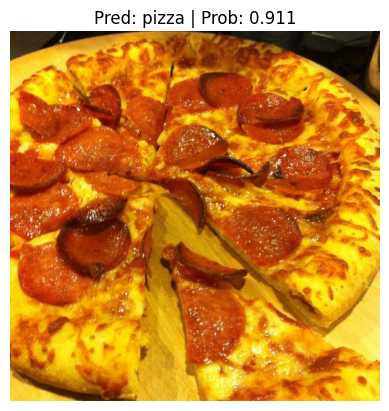

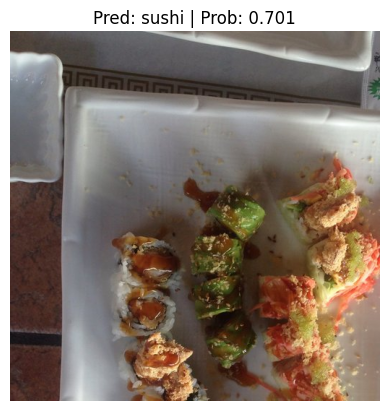

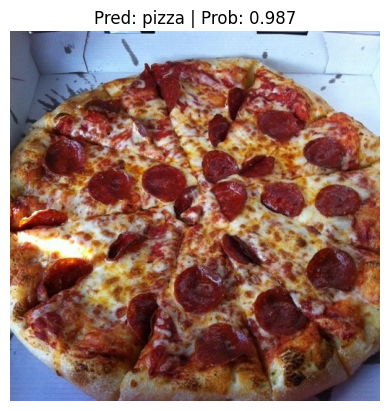

In [37]:
# Import function to make prediction on images and plot them
from going_modular.going_modular.predictions import pred_and_plot_image

# Get a random list of 3 image path names from the best path
import random
num_images_to_plot = 3
test_image_path_list = list(Path(data_20_percent_path / "test").glob("*/*.jpg"))
test_image_path_sample = random.sample(test_image_path_list, k=num_images_to_plot)

for image_path in test_image_path_sample:
    pred_and_plot_image(model=best_model,
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224, 224))

### 9.1 Predict on a custom image with the best model

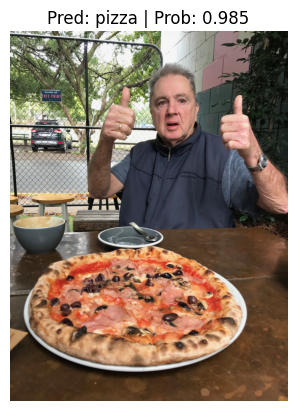

In [38]:
custom_image_path = Path("data/04-pizza-dad.jpeg")
# Predict on our own custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names = class_names)